# K-means - Aprendizaje no supervisado

> **Concenptos:**  
>  
> 
> **1- Clustering = Agrupar filas (observaciones)** 
>       - Se agrupan las filas, no las columnas.  
>       - Cada fila representa una casa del dataset.  
>       - Las columnas son las features [['Latitude', 'Longitude', 'MedInc']]  
> **2- ¿Cómo funciona K-Means?** 
> El algoritmo:  
>       - Elige k centroides aleatorios.  
>       - Asigna cada punto al centroide más cercano (distancia euclidiana).  
>       - Recalcula los centroides.  
>       - Repite hasta converger.  
>       - Minimiza la distancia dentro de cada grupo.

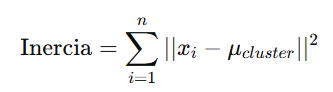

  
  > **3- Train vs Test en K-Means**  
  > En aprendizaje NO supervisado:    
  >     - No hay 'y real' para entrenar.Es decir, no le damos al modelo la columna con la respuesta.  
  >     - Solo usamos X.  
  >   
  >   | Dataset | Uso                                        |  
  > | ------- | ------------------------------------------ |  
  > | X_train | Entrenar KMeans                            |  
  > | X_test  | Ver si el modelo generaliza                |  
  > | y       | No se usa (porque el modelo busca patrones) |  
  >
  >
  > **¿Por qué usamos X?**  
  >     - Porque K-Means aprende estructura interna de los datos.  
  >     - No predice una variable objetivo.  
  >  
  >
  > **4- Normalización**; ¿Se normaliza X --> Sí, MUY importante.  
  >     - K-Means usa distancia euclidiana    
  >     - Si una variable tiene escala grande (ej: Population), dominará el clustering  
  > Por eso usamos:   
  > from sklearn.preprocessing import StandardScaler  
  > scaler = StandardScaler()  
  > X_scaled = scaler.fit_transform(X)  
  >  
  >
> **5- ¿Qué es PCA?** (PCA = Principal Component Analysis)
> Es una técnica de:  
>       - Reducción de dimensionalidad.  
>       - Proyección a nuevas variables.  
>       - Mantener la mayor varianza posible.  
> **¿Para qué se usa con K-Means?**  
>       - Visualizar clusters en 2D.  
>       - Reducir ruido .
>       - DUDA: Mejorar separación.  
> **¿Por qué se vuelve a escalar?**
>       - Porque PCA depende de la varianza.  <-- DUDA>
>       - Si no escalas, las variables grandes dominan las componentes principales.

# (0) Imports

In [114]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Para reproducibilidad
RANDOM_STATE = 42

# **EDA - California Housing**

## (1) Lectura e interpretación de los datos

In [103]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv", sep=",")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


> **Observaciones**
>
>    - La 1ª columna "#" indica el índex de las variables y la 2ª su nombre/indicador.
>    - La 3ª columna cuenta los valores no nulos, es decir dónde sí tenemos data en cada fila. En este DataSet no existen valores faltantes.
>    - La 4ª columna nos dice el tipo de dato que contienen las variables, numéricos o objeto-string. En este caso tenemos solamente data numérica.
>    - Por último tenemos un recuento de los tipo de variable y cuánto ocupa en la memoria el total del df.
>    - Hay 20640 filas y 9 columnas.

> **Las variables del DataSet**  
>  
> - MedInc: Ingreso medio de los hogares en el grupo de bloques.  
> - HouseAge: Edad media de la vivienda en el grupo de bloques.  
> - AveRooms: Número promedio de habitaciones por hogar.  
> - AveBedrms: Número promedio de dormitorios por hogar.  
> - Population: Población total del grupo de bloques.  
> - AveOccup: Promedio de miembros del hogar (ocupación).  
> - Latitude: Latitud del grupo de bloques.  
> - Longitude: Longitud del grupo de bloques.

> **Objetivo:** Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio.  
>  
> **Hipótesis del Proyecto:** Existen patrones geográficos claros en California donde el ingreso medio (MedInc) está fuertemente correlacionado con la ubicación, permitiendo identificar grupos específicos (clusters) que separan zonas costeras de alto nivel económico de zonas interiores o rurales.

## (2) Procesado de datos 

### (1) Limpieza de datos

* **Valores NaNs**

In [105]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

* **Valores duplicados**

> DUDA: porque es distinto "df.duplicated().count()" y "df.duplicated().sum()"

In [106]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [107]:
df.duplicated().count()

np.int64(20640)

In [108]:
df.apply(lambda x: x.duplicated().sum())


MedInc          7712
HouseAge       20588
AveRooms        1248
AveBedrms       6407
Population     16752
AveOccup        1799
Latitude       19778
Longitude      19796
MedHouseVal    16798
dtype: int64

In [109]:
df.duplicated().sum()

np.int64(0)

### (2) Distribución de la data

In [110]:
df['MedInc'].sort_values(ascending=False)

5281     15.0001
6727     15.0001
6736     15.0001
5275     15.0001
17110    15.0001
          ...   
20091     0.4999
6688      0.4999
7125      0.4999
6343      0.4999
5213      0.4999
Name: MedInc, Length: 20640, dtype: float64

In [111]:
df['HouseAge'].sort_values(ascending=False)

7        52.0
20592    52.0
6        52.0
5        52.0
4        52.0
         ... 
18942     2.0
19536     1.0
12286     1.0
18972     1.0
3130      1.0
Name: HouseAge, Length: 20640, dtype: float64

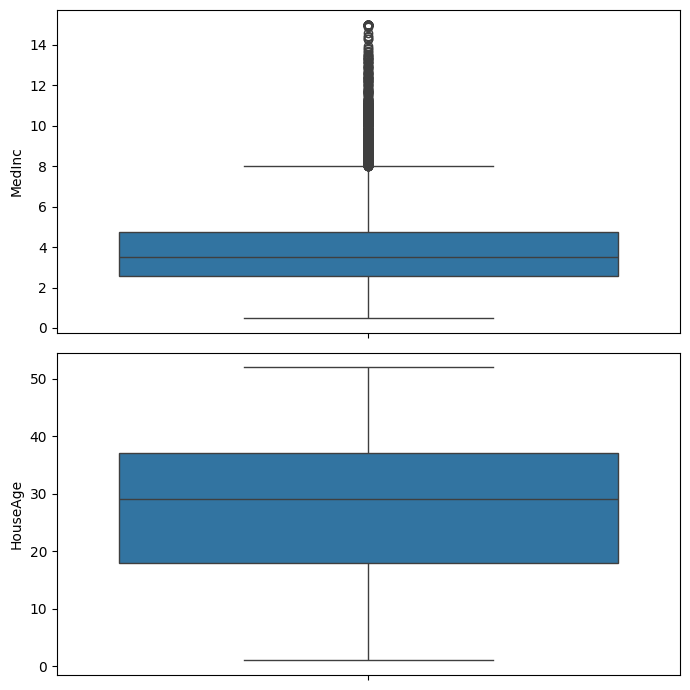

In [112]:
fig, axis = plt.subplots(2, figsize = (7, 7))

sns.boxplot(ax = axis[0], data = df, y = 'MedInc')
sns.boxplot(ax = axis[1], data = df, y = 'HouseAge')


plt.tight_layout()

plt.show()

Corregir grafico 3d

In [113]:
import plotly.express as px
import plotly.express as px
px.scatter_3d(
    df,
    x="MedInc",
    y="AveRooms",
    z="AveOccup",
    color="MedInc",
    width=1000,
    height=600
).show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

* **Métodos IQR- DUDA son métodos cuantiles?**

In [ ]:
Q1 = df['MedInc'].quantile(0.25)
Q3 = df['MedInc'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['MedInc'] < Q1 - 1.5*IQR) | 
              (df['MedInc'] > Q3 + 1.5*IQR)]

print(outliers.shape)

(681, 9)


## (3) Selección de variables objetivo

In [ ]:
df = df[['Latitude', 'Longitude', 'MedInc']]
print(df.info()) 
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB
None
           Latitude     Longitude        MedInc
count  20640.000000  20640.000000  20640.000000
mean      35.631861   -119.569704      3.870671
std        2.135952      2.003532      1.899822
min       32.540000   -124.350000      0.499900
25%       33.930000   -121.800000      2.563400
50%       34.260000   -118.490000      3.534800
75%       37.710000   -118.010000      4.743250
max       41.950000   -114.310000     15.000100


> **Observaciones:** Los datos no presentan valores faltantes (NaNs). Sin embargo, las escalas de Latitude/Longitude y MedInc son muy diferentes, lo que hace indispensable el escalado posterior para que K-Means (que usa distancia euclidiana) funcione correctamente.

# **ML - Kmeans**

## (1) Split Data

* **Variables para clustering**

In [ ]:
X = df[['Latitude','Longitude','MedInc']]

* **Se divide el conjunto de datos (80% entrenamiento, 20% prueba)**

In [ ]:
X_train, X_test = train_test_split(X,test_size=0.2,random_state=42) # Train Test Split

# Copia del df para evitar warnings
X_train = X_train.copy()
X_test = X_test.copy()

* **Normalización de los datos**

> K-Means se basa en distancias (euclídeas). Si una feature tiene escala mayor, dominará el resultado.
Por eso usamos **StandardScaler** (media 0, desviación 1).


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Probar distintos k** 

> (1) Calcular Silhouette Score
> - **Silhouette Score** va de -1 a 1.
> - Valores más altos suelen indicar clusters más separados y compactos.
> - Recomendación práctica: probar k en un rango razonable (por ejemplo 2 a 10).  
> **Importante:** silhouette no es perfecto; a veces conviene combinarlo con sentido de negocio/interpretación.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
k_range = range(2,7)

for k in k_range:  
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')  
    labels = kmeans.fit_predict(X_train_scaled)  
    score = silhouette_score(X_train_scaled, labels)  
    scores.append(score)
print(f"k={k} silhouette={score:.3f}")

k=6 silhouette=0.398


## (2) Entrenamiento del modelo

### **K-means**

In [ ]:
nk_6 = 6
kmeans = KMeans(n_clusters=k_6, random_state=42, n_init='auto')
X_train['cluster'] = kmeans.fit_predict(X_train_scaled)

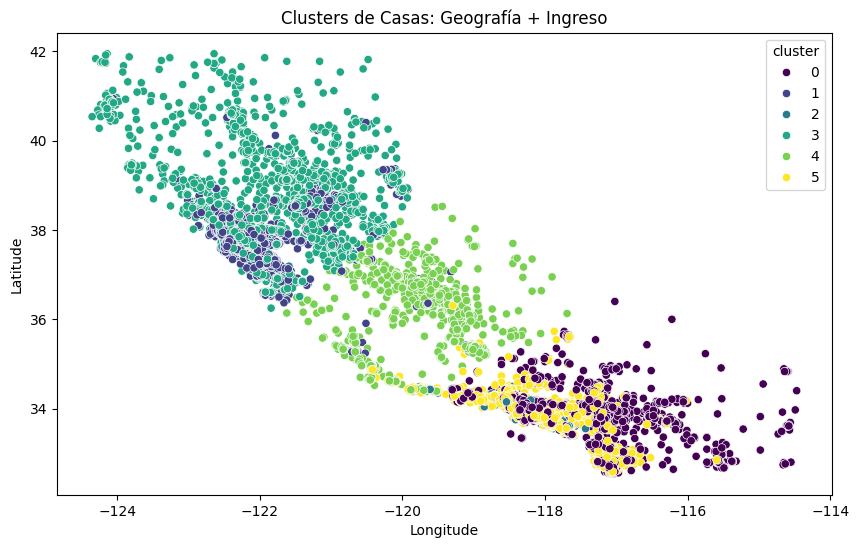

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_train, x='Longitude', y='Latitude', hue='cluster', palette='viridis')
plt.title('Clusters de Casas: Geografía + Ingreso')
plt.show()

### **Comparación con modelo supervisado Random Forest:**

* **Preparar etiquetas para supervisado**


In [116]:
y_train = X_train['cluster']
X_test['cluster_predicted_kmeans'] = kmeans.predict(X_test_scaled)



* **Entrenar Clasificador Supervisado (Random Forest)**

In [117]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

* **Predicción y Evaluación**

In [118]:
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Precisión del Random Forest para predecir clusters: {accuracy_score(X_test['cluster_predicted_kmeans'], y_pred_rf):.4f}")

Precisión del Random Forest para predecir clusters: 0.9937


> **Nota:** Este flujo permite automatizar la etiquetación. Mientras K-Means encuentra la estructura inherente (No Supervisado), el Random Forest (Supervisado) aprende las reglas de decisión que definen esos grupos.

#### Graficos 3D  no funcionan

**Plot solo varibales Geográficas**

In [ ]:
df['cluster_geo'] = KMeans(n_clusters=6, random_state=42, n_init='auto')\
    .fit_predict(df[['Longitude','Latitude']])
df['cluster_geo']

0        1
1        1
2        1
3        1
4        1
        ..
20635    4
20636    4
20637    4
20638    4
20639    4
Name: cluster_geo, Length: 20640, dtype: int32

**Plot solo varibales Socioeconómicas**

In [ ]:
df['cluster_income'] = KMeans(n_clusters=6, random_state=42, n_init='auto')\
    .fit_predict(df[['MedInc']])
df['cluster_income']

0        4
1        4
2        4
3        2
4        0
        ..
20635    1
20636    5
20637    1
20638    1
20639    1
Name: cluster_income, Length: 20640, dtype: int32

In [ ]:
# error: Mime type rendering requires nbformat>=4.2.0 but it is not installed-> $ pip install nbformat No funciona
# import pandas as pd
# import plotly.express as px
#
# # Verifica que las columnas necesarias existen
# print(df[['Longitude', 'Latitude', 'MedInc']].info())  # Esto mostrará información sobre las columnas necesarias

# # Crear el gráfico 3D
# fig = px.scatter_3d(
#     df,
#     x="Longitude",
#     y="Latitude",
#     z="MedInc",
#     width=1000,
#     height=500,
#     color_discrete_sequence=["#E58139","#39E581", "#8139E5"]  # Puedes usar un solo color si no necesitas categorizar
# )

# camera = dict(up=dict(x=0, y=0, z=1), eye=dict(x=2, y=2, z=2))
# fig.update_layout(scene_camera=camera)
# fig.show()

### **Elbow Method**

* **Calcular inercia para distintos valores de k** DUDA: no recuerdo apr aqeu sirve

**Método del Codo (Elbow Method)**
DUDA: Investiga Qué es?

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
elbow_vis = KElbowVisualizer(KMeans(random_state=18), k=(2, 20))
elbow_vis.fit(X)
elbow_vis.show()

ModuleNotFoundError: No module named 'yellowbrick'

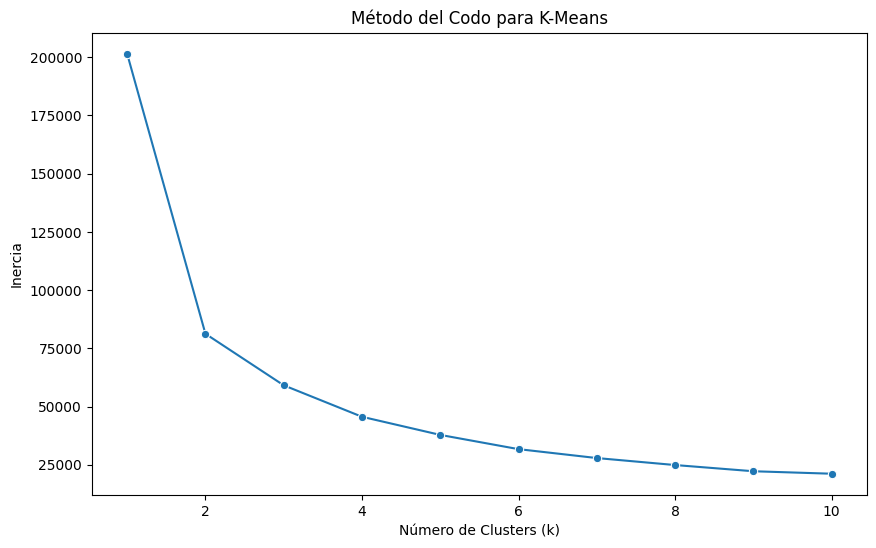

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train[['Latitude', 'Longitude', 'MedInc']])
    inertia.append(kmeans.inertia_)

# Graficar
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(k_range), y=inertia, marker='o')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.show()

####  **Chequeo rápido: medias ~0 y std ~1 (aprox)**

> ¿Qué debería salir?  
> Mean ≈ 0  
> Std ≈ 1  

> ¿Qué es desviación estándar?  
> Mide cuánto se dispersan los datos respecto a la media.  
> Ejemplo simple:  
> Datos: 10, 10, 10 → std = 0  
> Datos: 1, 100, 1000 → std alta  
> Después de escalar:  
> Media = 0  
> Desviación estándar = 1  
> Eso asegura que todas las variables tengan el mismo peso.



In [ ]:
print("Mean (first 5 features):", X_scaled.mean(axis=0)[:5])
print("Std  (first 5 features):", X_scaled.std(axis=0)[:5])

NameError: name 'X_scaled' is not defined

> **Observaciones**: DUDA-> Qué indica la desviación estandar?  
> Explicar sobre resultados de muestras [:5]

### **Observaciones Conclusión k=2 vs k=6**

  
  > Por qué 6 podría ser mejor que 2?  No es porque el algoritmo "prefiera" 6.  
  > Es porque:  
  > - Con k=2 fuerzas solo 2 regiones → probablemente demasiado general.  
  > - Con k=6 permites más estructura espacial.  
  > - Imagina California:  
  > - Norte rico  
  > - Norte pobre  
  > - Sur rico  
  > - Sur pobre  
  > - Costa  
  > - Interior  
  > Con 2 clusters estás simplificando demasiado.

## 5) PCA para visualizar en 2D

PCA reduce dimensionalidad. Aquí lo usamos SOLO para **graficar** en 2D.

- Ajustamos PCA con 2 componentes sobre `X_scaled`.
- Proyectamos a 2D.
- Graficamos puntos coloreados por cluster.

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza explicada total (2 componentes):", pca.explained_variance_ratio_.sum())


Varianza explicada por componente: [0.64230926 0.33429319]
Varianza explicada total (2 componentes): 0.9766024491603789


In [ ]:
k_optimo = 6

# Definimos el modelo K-Means final usando ese 'k'
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')

# Entrenamos el modelo con los datos escalados y obtenemos las "etiquetas"
# (es decir, el número de clúster asignado a cada fila)
etiquetas_finales = kmeans_final.fit_predict(X_train_scaled)

# Opcional: Imprimimos las primeras 10 etiquetas para ver cómo se ven
print("Los clústeres asignados a las primeras 10 casas son:")
print(etiquetas_finales[:10])

Los clústeres asignados a las primeras 10 casas son:
[0 3 0 3 0 3 3 3 5 3]


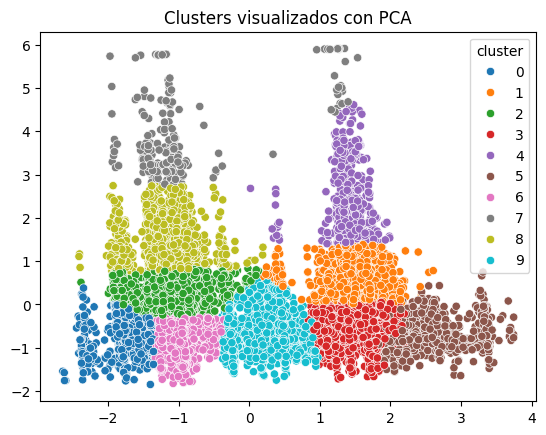

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=X_train["cluster"],
    palette="tab10"
)

plt.title("Clusters visualizados con PCA")
plt.show()

## **Conclusión conceptual para tu reporte**

* **Validación de Hipótesis:** El clustering confirma que el ingreso medio no se distribuye al azar, sino que sigue patrones geográficos en California
* **Importancia del Escalado:** Sin la normalización, el ingreso medio (MedInc) habría tenido menos peso que las coordenadas geográficas debido a sus magnitudes
* **Sinergia de Modelos:** El uso de K-Means para generar etiquetas "pseudo-reales" permite aplicar modelos supervisados en contextos donde originalmente no había categorías definidas


Puedes escribir algo como:

Se aplicó K-Means clustering utilizando Latitude, Longitude y MedInc. Se evaluaron diferentes valores de k mediante el método del codo. Se seleccionó k=6 debido a una reducción significativa en la inercia sin sobresegmentar los datos. Se aplicó estandarización previa para evitar sesgos derivados de diferencias de escala. PCA fue utilizado para visualización y análisis estructural del espacio de característica


* DUDA:REVISAR


Se aplicó el algoritmo K-Means para segmentar regiones de viviendas en California utilizando variables geográficas y socioeconómicas (Latitude, Longitude y MedInc).

Los datos fueron estandarizados mediante StandardScaler para evitar sesgos derivados de diferencias de escala entre variables.

Se evaluaron distintos valores de k mediante Silhouette Score y el método del codo.

Finalmente se seleccionó k=6 para obtener una segmentación geográfica más detallada del mercado inmobiliario.